In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("country_wise_latest.csv")
df.head()


,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [5]:
df["Active"] = pd.to_numeric(df["Active"], errors="coerce")
df["Confirmed"] = df["Confirmed"].fillna(0)
df["Deaths"] = df["Deaths"].fillna(0)
df["Recovered"] = df["Recovered"].fillna(0)
df["Country/Region"] = df["Country/Region"].replace({
    "US": "USA",
    "United States": "USA",
    "Mainland China": "China",
    "UK": "United Kingdom"
})


In [7]:
india = df[df["Country/Region"] == "India"]
india.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
79,India,1480073,33408,951166,495499,44457,637,33598,2.26,64.26,3.51,1155338,324735,28.11,South-East Asia


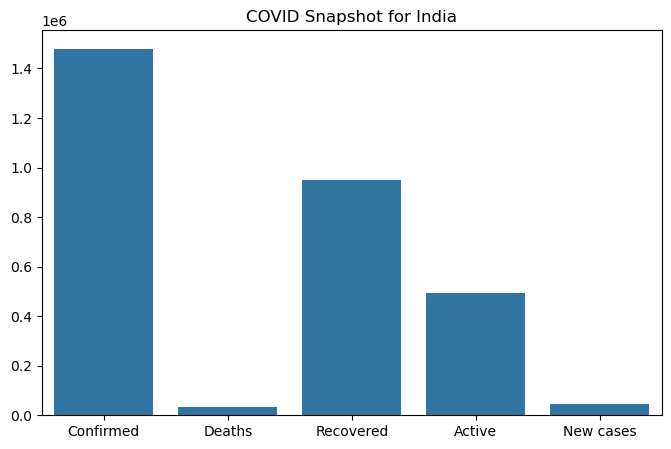

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(x=["Confirmed","Deaths","Recovered","Active","New cases"],
            y=[india["Confirmed"].values[0],
               india["Deaths"].values[0],
               india["Recovered"].values[0],
               india["Active"].values[0],
               india["New cases"].values[0]])
plt.title("COVID Snapshot for India")
plt.show()


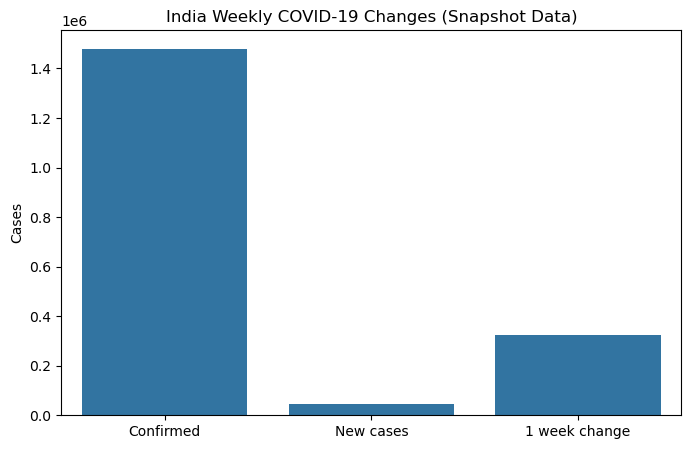

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(x=["Confirmed", "New cases", "1 week change"],
            y=[india["Confirmed"].values[0],
               india["New cases"].values[0],
               india["1 week change"].values[0]])
plt.title("India Weekly COVID-19 Changes (Snapshot Data)")
plt.ylabel("Cases")
plt.show()


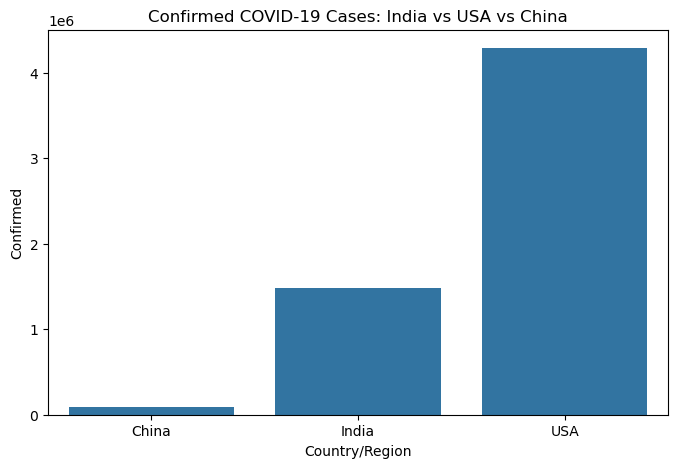

In [19]:
countries = ["India", "USA", "China"]

compare_df = df[df["Country/Region"].isin(countries)]
compare_df
plt.figure(figsize=(8,5))
sns.barplot(data=compare_df, x="Country/Region", y="Confirmed")
plt.title("Confirmed COVID-19 Cases: India vs USA vs China")
plt.show()
